# Preparación entomológica 2024 a nivel de grilla

1. **Objetivo del notebook**

- Preparar los hallazgos del periodo epidemiológico 2024, asignarles coordenadas y una celda de la grilla, y generar un producto final semanal junto con antecedentes individuales, agregados y un mapa de diagnóstico.

2. **Decisiones metodológicas**

- Seleccionar el periodo epidemiológico 2024 y agregar los hallazgos por grilla y semana epidemiológica.
- Usar el CSV como fuente de coordenadas de ovitrampas, vinculadas a los hallazgos mediante su ID.
- Para hallazgos sin ID, usar el punto original si existe; en su defecto, estimar la ubicación con el centroide de las ovitrampas del distrito. Estas aproximaciones se identifican como proxies; el antecedente agregado separa sus conteos de los exactos y el producto final reúne ambos en los totales asignados.
- Conservar los registros sin celda asignada en la base individual y excluirlos del agregado por grilla.
- Mantener los conteos faltantes como nulos y distinguir las sumas parciales. Una semana sin registros no implica ausencia de vigilancia ni de vectores.

3. **Fuentes**

- Shapefile de hallazgos, catálogo CSV de ovitrampas en `data/raw/entomology`.
- `data/processed/environment/grid_geometry.parquet`, generado por `environmental/01_data_aggregation.ipynb`.

4. **Productos**

Los tres archivos Parquet se guardan en `data/processed/entomology/`:

| Archivo | Contenido y uso |
|---|---|
| `entomology_2024_clean.parquet` | Producto final por grilla y semana. Contiene nueve columnas: `grid_id`, `year`, `epiweek`, `total registros`, `hallazgos vectores`, `huevos`, `larvas`, `pupas` y `adultos`. Reúne las asignaciones exactas y aproximadas. |
| `entomology_2024_records.parquet` | Antecedente individual de todos los hallazgos del periodo, incluidos los no asignables. Conserva conteos, fecha, coordenadas `lon`/`lat`, celda, método de ubicación y estado de asignación. Las coordenadas pueden ser aproximadas o faltar. No exporta `source_district_name` ni `record_key`. |
| `entomology_2024_grid_week.parquet` | Antecedente agregado completo por grilla y semana: separa registros y conteos exactos, proxy y totales asignados; incluye cantidad de IDs de ovitrampa y presencia de proxies. |

La figura `outputs/figures/entomology/proxy_spatial_diagnostic.png` muestra las ovitrampas del CSV, las ubicaciones aproximadas y los límites distritales en UTM 19S.

Al final del notebook se muestran las primeras 10 filas del producto final y del antecedente individual, leídas desde los archivos guardados.


La unidad analítica final es `grid_id + year + epiweek`. La procedencia territorial se conserva sólo para diagnosticar asignaciones proxy.

In [1]:
# Importa utilidades de rutas, análisis tabular, datos espaciales y gráficos.
from pathlib import Path
import sys, unicodedata
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Busca la raíz del proyecto subiendo desde el directorio de trabajo hasta encontrar src/paths.py.
for candidate in [Path.cwd(), *Path.cwd().resolve().parents]:
    if (candidate / 'src' / 'paths.py').is_file(): PROJECT_ROOT = candidate; break
else: raise FileNotFoundError('No se encontró src/paths.py.')
# Incorpora la raíz al buscador de módulos y carga calendario y rutas centralizadas.
sys.path.insert(0, str(PROJECT_ROOT))
from src.epidemiological_calendar import EPI_YEAR, assign_epiweek_2024, validate_epidemiological_range
from src.paths import (ENTOMOLOGY_CLEAN_PATH, ENTOMOLOGY_FIGURES_DIR, ENTOMOLOGY_GRID_WEEK_PATH, GRID_GEOMETRY_PATH, RAW_ENTOMOLOGY_FINDINGS_PATH, RAW_ENTOMOLOGY_OVITRAP_CSV_PATH)
# Ajusta la visualización de tablas y el estilo común de los gráficos.
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Carga y visualización general

Se cargan los hallazgos, el CSV de coordenadas de ovitrampas y la grilla.

In [2]:
# Comprueba que estén disponibles los hallazgos, el CSV de ovitrampas y la grilla.
inputs = [RAW_ENTOMOLOGY_FINDINGS_PATH, RAW_ENTOMOLOGY_OVITRAP_CSV_PATH, GRID_GEOMETRY_PATH]
missing = [str(p) for p in inputs if not p.is_file()]
if missing: raise FileNotFoundError(f'Faltan insumos: {missing}')
# Lee las fuentes sin modificar sus columnas originales.
findings_raw = gpd.read_file(RAW_ENTOMOLOGY_FINDINGS_PATH)
ovitrap_csv_raw = pd.read_csv(RAW_ENTOMOLOGY_OVITRAP_CSV_PATH)
grid_geometry = gpd.read_parquet(GRID_GEOMETRY_PATH)
# Muestra una vista inicial de cada fuente.
display(findings_raw.head()); display(ovitrap_csv_raw.head())

# Resume tipo, nulos, cardinalidad y una muestra de valores para cada columna.
def profile(frame, geometry_name=None):
    rows=[]
    for col in frame.columns:
        s=frame[col]; vals=(s.geom_type.dropna().astype('string').unique().tolist() if col==geometry_name else s.dropna().astype('string').unique().tolist()[:25])
        rows.append({'columna':col,'tipo':str(s.dtype),'no_nulos':int(s.notna().sum()),'nulos':int(s.isna().sum()),'pct_nulos':100*s.isna().mean(),'valores_unicos':int(s.nunique(dropna=True)),'valores_unicos_muestra':' | '.join(vals)})
    return pd.DataFrame(rows)
# Reporta estructura y contenido de las fuentes para detectar problemas antes de transformarlas.
print(f'Registros: {len(findings_raw):,}; CRS: {findings_raw.crs}; geometrías: {findings_raw.geometry.geom_type.value_counts().to_dict()}')
display(profile(findings_raw, findings_raw.geometry.name)); display(profile(ovitrap_csv_raw))


,CUT,N_REGION,N_PROVINCI,N_COMUNA,N_DISTRITO,COD_DISTRI,TIPO_DISTR,SHAPE_Leng,SHAPE_Area,ID_GENERAL,ID_ANUAL,CUT_REGION,CUT_PROVIN,CUT_COMUNA,NOM_REGION,NOM_PROVIN,NOM_COMUNA,FECHA,OBJETIVO,PREIDENTIF,HUEVO,LARVA,PUPA,ADULTO,OVITRAMPA,OBSERVACIO,FUENTE,ANIO,geometry
0,15101,ARICA Y PARINACOTA,ARICA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,46,1,15,151,15101,REGION ARICA Y PARINACOTA,ARICA,ARICA,15.01.2019,Vigilancia,-,28,0,0,0,56.0,Aedes aegypti,LABSAL,2019.0,"POLYGON ((-70.07834 -18.32225, -70.07835 -18.3..."
1,15101,ARICA Y PARINACOTA,ARICA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,47,2,15,151,15101,REGION ARICA Y PARINACOTA,ARICA,ARICA,18.01.2019,Vigilancia,Aedes aegypti,0,0,0,1,NaN,Aedes aegypti,LABSAL,2019.0,"POLYGON ((-70.07834 -18.32225, -70.07835 -18.3..."
2,15101,ARICA Y PARINACOTA,ARICA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,48,3,15,151,15101,REGION ARICA Y PARINACOTA,ARICA,ARICA,18.01.2019,Vigilancia,-,22,0,0,0,57.0,Aedes aegypti,LABSAL,2019.0,"POLYGON ((-70.07834 -18.32225, -70.07835 -18.3..."
3,15101,ARICA Y PARINACOTA,ARICA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,49,4,15,151,15101,REGION ARICA Y PARINACOTA,ARICA,ARICA,29.01.2019,Vigilancia,-,45,0,0,0,121.0,Aedes aegypti,LABSAL,2019.0,"POLYGON ((-70.07834 -18.32225, -70.07835 -18.3..."
4,15101,ARICA Y PARINACOTA,ARICA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,50,5,15,151,15101,REGION ARICA Y PARINACOTA,ARICA,ARICA,05.02.2019,Vigilancia,-,80,0,0,0,1.0,Aedes aegypti,LABSAL,2019.0,"POLYGON ((-70.07834 -18.32225, -70.07835 -18.3..."


,ovitrampa_id,utm19s_x,utm19s_y,lon,lat
0,1,363505,7965314,-70.292200,-18.397824
1,19,364266,7958643,-70.285445,-18.458152
2,22,363647,7958548,-70.291312,-18.458970
3,30,364153,7959421,-70.286463,-18.451114
4,46,364224,7954156,-70.286145,-18.498693


Registros: 244; CRS: EPSG:4674; geometrías: {'Polygon': 244}


,columna,tipo,no_nulos,nulos,pct_nulos,valores_unicos,valores_unicos_muestra
0,CUT,int64,244,0,0.000000,2,15101 | 15102
1,N_REGION,str,244,0,0.000000,1,ARICA Y PARINACOTA
2,N_PROVINCI,str,244,0,0.000000,1,ARICA
3,N_COMUNA,str,244,0,0.000000,2,ARICA | CAMARONES
4,N_DISTRITO,str,244,0,0.000000,13,CHACALLUTA | CHINCHORRO | CANCHA RAYADA | PEDR...
5,COD_DISTRI,float64,244,0,0.000000,13,15.0 | 3.0 | 18.0 | 17.0 | 6.0 | 4.0 | 2.0 | 1...
6,TIPO_DISTR,str,244,0,0.000000,3,RURAL | MIXTO | URBANO
7,SHAPE_Leng,float64,244,0,0.000000,13,0.93374658115 | 0.19351156892 | 0.08320701822 ...
8,SHAPE_Area,float64,244,0,0.000000,13,0.03553589019 | 0.00099326218 | 0.00032958643 ...
9,ID_GENERAL,int64,244,0,0.000000,242,46 | 47 | 48 | 49 | 50 | 51 | 52 | 53 | 54 | 5...


,columna,tipo,no_nulos,nulos,pct_nulos,valores_unicos,valores_unicos_muestra
0,ovitrampa_id,int64,213,0,0.0,213,1 | 19 | 22 | 30 | 46 | 49 | 56 | 57 | 62 | 76...
1,utm19s_x,int64,213,0,0.0,202,363505 | 364266 | 363647 | 364153 | 364224 | 3...
2,utm19s_y,int64,213,0,0.0,201,7965314 | 7958643 | 7958548 | 7959421 | 795415...
3,lon,float64,213,0,0.0,207,-70.2922 | -70.285445 | -70.291312 | -70.28646...
4,lat,float64,213,0,0.0,209,-18.397824 | -18.458152 | -18.45897 | -18.4511...


## 2. Limpieza, calendario y nulos

Se preparan los registros, se filtra el periodo epidemiológico y se revisan los faltantes. Los registros sin ID de ovitrampa se conservan.

### 2.1. Preparación de columnas

Se eliminan los campos administrativos definidos como prescindibles y se conserva el distrito de procedencia. Las funciones auxiliares reconocen nombres de columnas y también se usan en la sección 3. Fechas y conteos no interpretables se convierten en nulos; no se imputan valores.

`total_vectores` suma los conteos disponibles: puede ser parcial. `conteo_vector_completo` indica si las cuatro etapas tienen datos.

In [3]:
VECTOR_FORMS = ['HUEVO', 'LARVA', 'PUPA', 'ADULTO']

def norm(x):
    return ''.join(ch for ch in unicodedata.normalize('NFKD',str(x)).encode('ascii','ignore').decode().upper() if ch.isalnum())
def first(frame, names):
    m={norm(c):c for c in frame.columns}
    return next((m[norm(n)] for n in names if norm(n) in m), None)
district_id_col=first(findings_raw,['COD_DISTRI','ID_DISTRITO','N_DISTRITO','DISTRITO'])
district_name_col=first(findings_raw,['NOM_DISTRITO','N_DISTRITO','DISTRITO','TIPO_DISTR'])
# Crea la tabla de trabajo, conserva la procedencia y convierte fecha y conteos a tipos analizables.
records=findings_raw.drop(columns=[c for c in ['CUT','NOM_REGION','N_COMUNA','NOM_PROVIN','CUT_REGION','CUT_PROVIN','ID_GENERAL'] if c in findings_raw]).copy()
records['source_district_id']=findings_raw[district_id_col].astype('string') if district_id_col else pd.Series(pd.NA,index=records.index,dtype='string')
records['source_district_name']=findings_raw[district_name_col].astype('string') if district_name_col else records['source_district_id']
records['fecha_dt']=pd.to_datetime(records['FECHA'],dayfirst=True,errors='coerce')
records[VECTOR_FORMS]=records[VECTOR_FORMS].apply(pd.to_numeric,errors='coerce')
records['total_vectores']=records[VECTOR_FORMS].sum(axis=1,min_count=1)
records['conteo_vector_completo']=records[VECTOR_FORMS].notna().all(axis=1)

### 2.2. Selección del periodo

La tabla muestra cuántos registros se conservan en 2024 epidemiológico y distingue los descartados por fecha fuera del periodo de los que no tienen una fecha interpretable.

In [4]:
records['year'] = EPI_YEAR
records['epiweek'] = assign_epiweek_2024(records.fecha_dt)
records_2024 = records.loc[records.epiweek.notna()].copy()
validate_epidemiological_range(records_2024)

display(pd.DataFrame({
    'resultado': ['Registros originales', 'Conservados en 2024 epidemiologico',
                  'Fuera del periodo con fecha valida', 'Sin fecha interpretable'],
    'registros': [len(records), len(records_2024),
                  int((records.fecha_dt.notna() & records.epiweek.isna()).sum()),
                  int(records.fecha_dt.isna().sum())],
}))

,resultado,registros
0,Registros originales,244
1,Conservados en 2024 epidemiologico,85
2,Fuera del periodo con fecha valida,158
3,Sin fecha interpretable,1


### 2.3. Columnas con datos faltantes

Se muestran únicamente las columnas con nulos en los registros seleccionados. Una tabla vacía indica que no se encontraron faltantes.

In [5]:
nulls = records_2024.isna().sum().rename('nulos').to_frame()
nulls['pct_nulos'] = 100 * nulls.nulos / max(len(records_2024), 1)
display(nulls.loc[nulls.nulos.gt(0)].sort_values('nulos', ascending=False))

,nulos,pct_nulos
OVITRAMPA,78,91.764706
LARVA,2,2.352941
PUPA,2,2.352941
ADULTO,2,2.352941


### 2.4. Faltantes de conteos por semana

La tabla permite identificar semanas con conteos incompletos. `registros_con_conteo_incompleto` cuenta filas donde falta alguna de las cuatro etapas, no cualquier otra columna.

In [6]:
display(records_2024.groupby(['year','epiweek'],dropna=False).agg(
        registros=('epiweek','size'),
        registros_con_conteo_incompleto=('conteo_vector_completo',lambda s:int((~s).sum())),
        **{f'{c}_nulos':(c,lambda s:int(s.isna().sum())) for c in VECTOR_FORMS}
    ).reset_index())

,year,epiweek,registros,registros_con_conteo_incompleto,HUEVO_nulos,LARVA_nulos,PUPA_nulos,ADULTO_nulos
0,2024,5,1,0,0,0,0,0
1,2024,8,1,0,0,0,0,0
2,2024,9,1,0,0,0,0,0
3,2024,11,25,0,0,0,0,0
4,2024,12,11,0,0,0,0,0
5,2024,13,14,0,0,0,0,0
6,2024,14,7,0,0,0,0,0
7,2024,15,2,0,0,0,0,0
8,2024,16,2,1,0,1,1,1
9,2024,17,6,0,0,0,0,0


### 2.5. Registros con y sin ID de ovitrampa

Se comparan la cantidad de registros, los vectores contabilizados y los faltantes por etapa según la presencia de un ID. Tener ID no garantiza que exista una coincidencia en el CSV; ese cruce se realiza más adelante.

In [7]:
records_2024['con_id'] = records_2024.OVITRAMPA.notna()
display(records_2024.groupby('con_id').agg(
        registros=('con_id','size'),
        total_vectores=('total_vectores',lambda s:s.sum(min_count=1)),
        **{f'{c}_nulos':(c,lambda s:int(s.isna().sum())) for c in VECTOR_FORMS}
    ).reset_index())

,con_id,registros,total_vectores,HUEVO_nulos,LARVA_nulos,PUPA_nulos,ADULTO_nulos
0,False,78,3423.0,0,0,0,0
1,True,7,190.0,0,2,2,2


## 3. Coordenadas de ovitrampas desde el CSV

El CSV es la fuente de coordenadas de ovitrampas. Se validan sus identificadores y coordenadas y se crean los puntos en UTM 19S y longitud/latitud.

In [8]:
# Encuentra de manera no ambigua la columna identificadora de ovitrampa en el CSV.
def id_col(frame):
    cand=['ovitrampa_id','OVITRAMPA','ID_OVITRAMPA','ID','CODIGO','COD_OVITR']; found=[c for c in frame if norm(c) in {norm(x) for x in cand}]
    if len(found)!=1: raise ValueError(f'Columnas ID ambiguas o ausentes: {found}')
    return found[0]
# Localiza ID y coordenadas geográficas/UTM en el CSV.
csv_id=id_col(ovitrap_csv_raw); lon_col=first(ovitrap_csv_raw,['lon','longitude','longitud']); lat_col=first(ovitrap_csv_raw,['lat','latitude','latitud']); x_col=first(ovitrap_csv_raw,['utm19s_x','x_utm19s','este','utm_x']); y_col=first(ovitrap_csv_raw,['utm19s_y','y_utm19s','norte','utm_y'])
if not all([lon_col,lat_col,x_col,y_col]): raise ValueError('Faltan lon/lat o UTM 19S en el CSV.')
# Construye el catálogo canónico desde el CSV y exige ID/coordenadas completos y únicos.
locations=pd.DataFrame({'ovitrampa_id':pd.to_numeric(ovitrap_csv_raw[csv_id],errors='coerce').astype('Int64'),'lon':pd.to_numeric(ovitrap_csv_raw[lon_col],errors='coerce'),'lat':pd.to_numeric(ovitrap_csv_raw[lat_col],errors='coerce'),'utm19s_x':pd.to_numeric(ovitrap_csv_raw[x_col],errors='coerce'),'utm19s_y':pd.to_numeric(ovitrap_csv_raw[y_col],errors='coerce')})
if locations.ovitrampa_id.isna().any() or locations.ovitrampa_id.duplicated().any() or locations[['lon','lat','utm19s_x','utm19s_y']].isna().any().any(): raise ValueError('CSV canónico con ID/coordenadas nulos o duplicados.')
# Crea los puntos del CSV en UTM 19S y longitud/latitud.
csv_utm=gpd.GeoDataFrame(locations,geometry=gpd.points_from_xy(locations.utm19s_x,locations.utm19s_y),crs='EPSG:32719'); csv_ll=gpd.GeoDataFrame(locations,geometry=gpd.points_from_xy(locations.lon,locations.lat),crs='EPSG:4326')
display(locations.head())
print(f"Ovitrampas con coordenadas: {len(locations):,}. Fuente: CSV.")


,ovitrampa_id,lon,lat,utm19s_x,utm19s_y
0,1,-70.292200,-18.397824,363505,7965314
1,19,-70.285445,-18.458152,364266,7958643
2,22,-70.291312,-18.458970,363647,7958548
3,30,-70.286463,-18.451114,364153,7959421
4,46,-70.286145,-18.498693,364224,7954156


Ovitrampas con coordenadas: 213. Fuente: CSV.


## 4. Asignación a `grid_id` y proxy explícito

Se priorizan las coordenadas exactas. Cuando no existen, se asigna un proxy por procedencia y se conserva el método utilizado.

In [9]:
# Prepara una clave estable por registro y normaliza el identificador de ovitrampa.
records_2024=records_2024.reset_index(drop=True); records_2024['record_key']=np.arange(len(records_2024)); records_2024['ovitrampa_id']=pd.to_numeric(records_2024.OVITRAMPA,errors='coerce').astype('Int64'); records_2024['source_geometry']=records_2024.geometry.tolist()
# Valida la grilla y proyecta el catálogo canónico al mismo CRS.
grid=grid_geometry[['grid_id','geometry']].copy()
catalog_grid=csv_ll[['ovitrampa_id','geometry']].to_crs(grid.crs).rename_geometry('candidate_geometry'); catalog_by_id=catalog_grid.set_index('ovitrampa_id')
# Si existen polígonos distritales, crea un punto proxy a partir de las ovitrampas del distrito.
district_polygons=None; district_catalog=pd.DataFrame(columns=['source_district_id','ovitrampa_id']); proxy_points={}; proxy_inside={}
if district_id_col and findings_raw.geometry.geom_type.isin(['Polygon','MultiPolygon']).any():
    poly=gpd.GeoDataFrame({'source_district_id':findings_raw[district_id_col].astype('string'),'geometry':findings_raw.geometry},crs=findings_raw.crs).dropna(subset=['source_district_id']).to_crs('EPSG:32719'); district_polygons=poly.dissolve('source_district_id',as_index=False)
    sj=gpd.sjoin(csv_utm[['ovitrampa_id','geometry']],district_polygons,how='left',predicate='within'); district_catalog=sj[['source_district_id','ovitrampa_id']].dropna().drop_duplicates()
    for d in district_polygons.source_district_id:
        pts=csv_utm.loc[csv_utm.ovitrampa_id.isin(district_catalog.loc[district_catalog.source_district_id.eq(d),'ovitrampa_id']), 'geometry']
        if len(pts)==1: proxy_points[d]=pts.iloc[0]
        elif len(pts)>1: proxy_points[d]=gpd.GeoSeries(pts.tolist(),crs='EPSG:32719').union_all().centroid
        if d in proxy_points: proxy_inside[d]=bool(proxy_points[d].within(district_polygons.loc[district_polygons.source_district_id.eq(d),'geometry'].iloc[0]))
# Selecciona una ubicación por prioridad: ID de ovitrampa, punto original o proxy distrital.
records_2024['location_method']=pd.NA; records_2024['location_is_proxy']=pd.Series(pd.NA,index=records_2024.index,dtype='boolean'); records_2024['candidate_geometry']=None; records_2024['grid_assignment_status']='missing_ovitrap_id'
for i,row in records_2024.iterrows():
    t=row.ovitrampa_id; geom=row.source_geometry
    if pd.notna(t) and int(t) in catalog_by_id.index: records_2024.loc[i,['candidate_geometry','location_method','location_is_proxy']]=[catalog_by_id.loc[int(t)].candidate_geometry,'ovitrap_id',False]
    elif pd.notna(t): records_2024.at[i,'grid_assignment_status']='missing_ovitrap_catalog_match'
    elif geom is not None and not pd.isna(geom) and geom.geom_type=='Point': records_2024.loc[i,['candidate_geometry','location_method','location_is_proxy']]=[gpd.GeoSeries([geom],crs=findings_raw.crs).to_crs(grid.crs).iloc[0],'source_point_geometry',False]
    elif pd.isna(row.source_district_id): records_2024.at[i,'grid_assignment_status']='missing_district'
    elif row.source_district_id not in proxy_points: records_2024.at[i,'grid_assignment_status']='no_ovitraps_in_district'
    else:
        records_2024.loc[i,['candidate_geometry','location_method','location_is_proxy']]=[gpd.GeoSeries([proxy_points[row.source_district_id]],crs='EPSG:32719').to_crs(grid.crs).iloc[0],'district_ovitrap_centroid_proxy',True]
        if not proxy_inside.get(row.source_district_id, False): records_2024.at[i,'grid_assignment_status']='proxy_outside_source_district'
# Cruza cada punto candidato con la grilla y registra si la asignación es exacta, proxy o fallida.
cand=records_2024.loc[records_2024.candidate_geometry.notna(),['record_key','candidate_geometry','location_is_proxy']]
if not cand.empty:
    joined=gpd.sjoin(gpd.GeoDataFrame(cand,geometry='candidate_geometry',crs=grid.crs),grid,how='left',predicate='within')
    for key,n in joined.groupby('record_key').grid_id.nunique(dropna=True).items():
        i=records_2024.index[records_2024.record_key.eq(key)][0]; ids=joined.loc[joined.record_key.eq(key),'grid_id'].dropna().unique()
        if records_2024.at[i,'grid_assignment_status']=='proxy_outside_source_district': continue
        if n==1: records_2024.loc[i,['grid_id','grid_assignment_status']]=[ids[0],'matched_proxy' if bool(records_2024.at[i,'location_is_proxy']) else 'matched_exact']
        elif n>1: records_2024.at[i,'grid_assignment_status']='ambiguous_spatial_match'
        else: records_2024.at[i,'grid_assignment_status']='proxy_outside_analysis_grid' if bool(records_2024.at[i,'location_is_proxy']) else 'outside_analysis_grid'
# Convierte las ubicaciones finalmente usadas a longitud/latitud y resume los estados.
records_2024['grid_id']=records_2024.get('grid_id',pd.Series(pd.NA,index=records_2024.index)).astype('string'); records_2024['lon']=pd.NA; records_2024['lat']=pd.NA
for i,g in records_2024.candidate_geometry.items():
    if g is not None and not pd.isna(g):
        ll=gpd.GeoSeries([g],crs=grid.crs).to_crs('EPSG:4326').iloc[0]; records_2024.loc[i,['lon','lat']]=[ll.x,ll.y]
display(records_2024.grid_assignment_status.value_counts(dropna=False).rename_axis('estado').reset_index(name='registros')); display(records_2024.groupby(['source_district_id','grid_assignment_status'],dropna=False).size().rename('registros').reset_index())


,estado,registros
0,matched_proxy,70
1,matched_exact,7
2,proxy_outside_analysis_grid,7
3,no_ovitraps_in_district,1


,source_district_id,grid_assignment_status,registros
0,15.0,matched_exact,7
1,15.0,matched_proxy,3
2,17.0,matched_proxy,1
3,18.0,matched_proxy,64
4,5.0,no_ovitraps_in_district,1
5,7.0,matched_proxy,2
6,8.0,proxy_outside_analysis_grid,7


## 5. Diagnósticos espaciales y productos

Se conservan como antecedentes el detalle individual y el agregado completo con asignaciones exactas y proxy. El producto final `entomology_2024_clean.parquet` contiene solo las nueve columnas seleccionadas, con los totales asignados por grilla y semana.

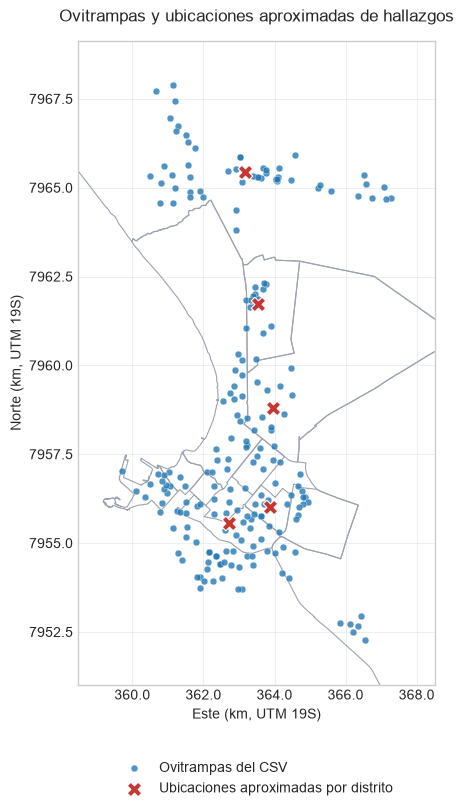

,categoria,cantidad
0,registros exactos,7.0
1,registros proxy,70.0
2,no asignables,8.0
3,vectores exactos,190.0
4,vectores proxy,3314.0
5,vectores asignados,3504.0


,etapa,asignacion,cantidad
0,HUEVO,exact,189.0
1,HUEVO,proxy,2013.0
2,HUEVO,assigned,2202.0
3,LARVA,exact,0.0
4,LARVA,proxy,1074.0
5,LARVA,assigned,1074.0
6,PUPA,exact,0.0
7,PUPA,proxy,116.0
8,PUPA,assigned,116.0
9,ADULTO,exact,1.0


,year,epiweek,registros,vectores,proxies
0,2024,5,1,1.0,0
1,2024,9,1,2.0,1
2,2024,11,25,1792.0,25
3,2024,12,11,671.0,11
4,2024,13,14,407.0,14
5,2024,14,7,18.0,7
6,2024,15,2,312.0,2
7,2024,16,2,10.0,1
8,2024,17,6,60.0,6
9,2024,18,1,27.0,0


Los nulos no son ceros; variables para imputación: conteos de vector y campos de ubicación/periodo que permanezcan nulos.


In [10]:
# Usa UTM 19S en todas las capas para comparar posiciones en metros.
from matplotlib.ticker import FuncFormatter

ENTOMOLOGY_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
map_crs = 'EPSG:32719'
map_catalog = catalog_grid.to_crs(map_crs)
map_proxies = gpd.GeoDataFrame(
    records_2024.loc[
        records_2024.location_is_proxy.eq(True) & records_2024.candidate_geometry.notna(),
        ['candidate_geometry'],
    ].copy(),
    geometry='candidate_geometry',
    crs=grid.crs,
).to_crs(map_crs).drop_duplicates(subset='candidate_geometry')

fig, ax = plt.subplots(figsize=(10, 8), layout='constrained')
if district_polygons is not None:
    district_polygons.to_crs(map_crs).boundary.plot(
        ax=ax, color='#9ca3af', linewidth=0.8, zorder=1,
    )
map_catalog.plot(
    ax=ax, color='#2378b5', markersize=24, alpha=0.8,
    edgecolor='white', linewidth=0.3, label='Ovitrampas del CSV', zorder=2,
)
if not map_proxies.empty:
    map_proxies.plot(
        ax=ax, color='#c63732', marker='X', markersize=110,
        edgecolor='white', linewidth=0.8,
        label='Ubicaciones aproximadas por distrito', zorder=3,
    )

# Centra la vista en las ubicaciones, evitando extensiones distritales alejadas.
map_points = pd.concat([map_catalog.geometry, map_proxies.geometry], ignore_index=True)
xmin, ymin, xmax, ymax = gpd.GeoSeries(map_points, crs=map_crs).total_bounds
padding = max(xmax - xmin, ymax - ymin) * 0.08
padding = max(padding, 250)
ax.set_xlim(xmin - padding, xmax + padding)
ax.set_ylim(ymin - padding, ymax + padding)
ax.set_aspect('equal')
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value / 1000:.1f}'))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value / 1000:.1f}'))
ax.set_xlabel('Este (km, UTM 19S)')
ax.set_ylabel('Norte (km, UTM 19S)')
ax.set_title('Ovitrampas y ubicaciones aproximadas de hallazgos', pad=14)
ax.grid(color='#e5e7eb', linewidth=0.5)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
fig.savefig(ENTOMOLOGY_FIGURES_DIR / 'proxy_spatial_diagnostic.png', dpi=180, bbox_inches='tight')
plt.show()
# Genera el producto limpio individual eliminando geometrías auxiliares y campos redundantes.
clean=records_2024.drop(columns=['source_geometry','candidate_geometry','geometry'],errors='ignore').copy(); clean['location_is_proxy']=clean.location_is_proxy.astype('boolean'); clean_output=clean.drop(columns=['FECHA','ANIO','source_district_name','record_key'],errors='ignore')
# Separa asignaciones exactas y proxy y prepara la agregación por celda y semana epidemiológica.
assigned=clean_output.loc[clean_output.grid_assignment_status.isin(['matched_exact','matched_proxy'])].copy(); key=['grid_id','year','epiweek']; idx=assigned.groupby(key).size().index; grid_week=pd.DataFrame(index=idx).reset_index(); exact=assigned.grid_assignment_status.eq('matched_exact'); proxy=assigned.grid_assignment_status.eq('matched_proxy')
# Agrega número de registros, ovitrampas y conteos de cada etapa, preservando su origen exacto/proxy.
def gc(mask): return assigned.loc[mask].groupby(key).size().reindex(idx,fill_value=0).to_numpy()
grid_week['n_hallazgo_records_exact']=gc(exact); grid_week['n_hallazgo_records_proxy']=gc(proxy); grid_week['n_hallazgo_records_assigned']=grid_week.n_hallazgo_records_exact+grid_week.n_hallazgo_records_proxy; grid_week['n_ovitrampas_exact']=assigned.loc[exact].groupby(key).ovitrampa_id.nunique().reindex(idx,fill_value=0).to_numpy()
def gs(mask,col): return assigned.loc[mask].groupby(key)[col].sum(min_count=1).reindex(idx).to_numpy()
for col in ['total_vectores',*VECTOR_FORMS]: grid_week[f'{col}_exact']=gs(exact,col); grid_week[f'{col}_proxy']=gs(proxy,col); grid_week[f'{col}_assigned']=assigned.groupby(key)[col].sum(min_count=1).reindex(idx).to_numpy()
grid_week['has_proxy_assignment']=grid_week.n_hallazgo_records_proxy.gt(0)
# Comprueba que cada total asignado sea igual a la suma de sus componentes exacto y proxy.
def validate_totals(frame, stage):
    assigned_total = frame[f'{stage}_assigned']
    component_total = frame[[f'{stage}_exact', f'{stage}_proxy']].sum(axis=1, min_count=1)
    if not np.isclose(assigned_total, component_total, equal_nan=True).all():
        raise ValueError(f'Inconsistencia exacto + proxy en {stage}.')
for stage in ['total_vectores',*VECTOR_FORMS]: validate_totals(grid_week,stage)
# Guarda los productos individual y agregado, y muestra auditorías finales sin tratar nulos como ceros.
ENTOMOLOGY_CLEAN_PATH.parent.mkdir(parents=True, exist_ok=True)
ENTOMOLOGY_GRID_WEEK_PATH.parent.mkdir(parents=True, exist_ok=True)
# Conserva el detalle individual y el agregado completo como antecedentes.
records_path = ENTOMOLOGY_CLEAN_PATH.with_name('entomology_2024_records.parquet')
clean_output.to_parquet(records_path, index=False)
grid_week.to_parquet(ENTOMOLOGY_GRID_WEEK_PATH, index=False)

# Producto final: una fila por grilla y semana con los totales asignados.
final_columns = {
    'grid_id': 'grid_id',
    'year': 'year',
    'epiweek': 'epiweek',
    'n_hallazgo_records_assigned': 'total registros',
    'total_vectores_assigned': 'hallazgos vectores',
    'HUEVO_assigned': 'huevos',
    'LARVA_assigned': 'larvas',
    'PUPA_assigned': 'pupas',
    'ADULTO_assigned': 'adultos',
}
final_output = grid_week[list(final_columns)].rename(columns=final_columns)
final_output.to_parquet(ENTOMOLOGY_CLEAN_PATH, index=False)
display(pd.DataFrame({'categoria':['registros exactos','registros proxy','no asignables','vectores exactos','vectores proxy','vectores asignados'],'cantidad':[int(exact.sum()),int(proxy.sum()),int((~clean_output.grid_assignment_status.isin(['matched_exact','matched_proxy'])).sum()),assigned.loc[exact,'total_vectores'].sum(min_count=1),assigned.loc[proxy,'total_vectores'].sum(min_count=1),assigned.total_vectores.sum(min_count=1)]}))
stage_audit=pd.DataFrame([(stage,kind,grid_week[f'{stage}_{kind}'].sum(min_count=1)) for stage in ['HUEVO','LARVA','PUPA','ADULTO','total_vectores'] for kind in ['exact','proxy','assigned']],columns=['etapa','asignacion','cantidad']); display(stage_audit)
display(assigned.groupby(['year','epiweek'],as_index=False).agg(registros=('epiweek','size'),vectores=('total_vectores',lambda s:s.sum(min_count=1)),proxies=('location_is_proxy','sum'))); print('Los nulos no son ceros; variables para imputación: conteos de vector y campos de ubicación/periodo que permanezcan nulos.')


## 6. Vista del parquet final

Primeras 10 filas de `entomology_2024_clean.parquet`, con las nueve columnas finales por grilla y semana.

In [11]:
display(pd.read_parquet(ENTOMOLOGY_CLEAN_PATH).head(10))


,grid_id,year,epiweek,total registros,hallazgos vectores,huevos,larvas,pupas,adultos
0,100.0,2024,5,1,1.0,0,0.0,0.0,1.0
1,100.0,2024,16,1,9.0,9,NaN,NaN,NaN
2,100.0,2024,18,1,27.0,27,NaN,NaN,NaN
3,100.0,2024,22,1,12.0,12,0.0,0.0,0.0
4,100.0,2024,49,1,65.0,65,0.0,0.0,0.0
5,100.0,2024,50,1,10.0,10,0.0,0.0,0.0
6,100.0,2024,52,1,66.0,66,0.0,0.0,0.0
7,102.0,2024,11,24,1791.0,1305,393.0,39.0,54.0
8,102.0,2024,12,10,670.0,386,259.0,19.0,6.0
9,102.0,2024,13,14,407.0,45,305.0,37.0,20.0


## 7. Vista de hallazgos individuales y coordenadas

Primeras 10 filas de `entomology_2024_records.parquet`. Conserva todos los hallazgos del periodo, con longitud (`lon`), latitud (`lat`), método de ubicación y estado de asignación. Las coordenadas pueden ser aproximadas o estar ausentes cuando no se pudo determinar una ubicación.

In [12]:
display(pd.read_parquet(records_path).head(10))


,N_REGION,N_PROVINCI,N_DISTRITO,COD_DISTRI,TIPO_DISTR,SHAPE_Leng,SHAPE_Area,ID_ANUAL,CUT_COMUNA,NOM_COMUNA,OBJETIVO,PREIDENTIF,HUEVO,LARVA,PUPA,ADULTO,OVITRAMPA,OBSERVACIO,FUENTE,source_district_id,fecha_dt,total_vectores,conteo_vector_completo,year,epiweek,con_id,ovitrampa_id,location_method,location_is_proxy,grid_assignment_status,grid_id,lon,lat
0,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,1,15101,ARICA,Vigilancia,-,0,0.0,0.0,1.0,124.0,Aedes aegypti,LABSAL,15.0,2024-01-30,1.0,True,2024,5,True,124,ovitrap_id,False,matched_exact,100.0,-70.287017,-18.398410
1,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,3,15101,ARICA,Vigilancia,Aedes aegypti,2,0.0,0.0,0.0,NaN,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-02-26,2.0,True,2024,9,False,<NA>,district_ovitrap_centroid_proxy,True,matched_proxy,61.0,-70.295322,-18.396713
2,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,8,15101,ARICA,DENUNCIA,Aedes aegypti,0,0.0,0.0,1.0,NaN,Aedes aegypti,LABSAL,15.0,2024-03-12,1.0,True,2024,11,False,<NA>,district_ovitrap_centroid_proxy,True,matched_proxy,61.0,-70.295322,-18.396713
3,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,35,15101,ARICA,DENUNCIA,Aedes aegypti,0,0.0,0.0,1.0,NaN,Aedes aegypti,LABSAL,15.0,2024-03-19,1.0,True,2024,12,False,<NA>,district_ovitrap_centroid_proxy,True,matched_proxy,61.0,-70.295322,-18.396713
4,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,63,15101,ARICA,Vigilancia,-,9,NaN,NaN,NaN,236.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-04-15,9.0,False,2024,16,True,236,ovitrap_id,False,matched_exact,100.0,-70.286326,-18.395804
5,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,71,15101,ARICA,Vigilancia,-,27,NaN,NaN,NaN,236.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-04-29,27.0,False,2024,18,True,236,ovitrap_id,False,matched_exact,100.0,-70.286326,-18.395804
6,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,79,15101,ARICA,Vigilancia,-,12,0.0,0.0,0.0,253.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-05-27,12.0,True,2024,22,True,253,ovitrap_id,False,matched_exact,100.0,-70.290451,-18.395568
7,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,83,15101,ARICA,Vigilancia,-,65,0.0,0.0,0.0,149.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-12-03,65.0,True,2024,49,True,149,ovitrap_id,False,matched_exact,100.0,-70.283167,-18.398680
8,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,84,15101,ARICA,Vigilancia,-,10,0.0,0.0,0.0,148.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-12-10,10.0,True,2024,50,True,148,ovitrap_id,False,matched_exact,100.0,-70.276073,-18.400770
9,ARICA Y PARINACOTA,ARICA,CHACALLUTA,15.0,RURAL,0.933747,0.035536,85,15101,ARICA,Vigilancia,-,66,0.0,0.0,0.0,149.0,Se observan huevos de Aedes aegypti,LABSAL,15.0,2024-12-23,66.0,True,2024,52,True,149,ovitrap_id,False,matched_exact,100.0,-70.283167,-18.398680


In [13]:
pd.read_parquet(ENTOMOLOGY_GRID_WEEK_PATH).head(10)

,grid_id,year,epiweek,n_hallazgo_records_exact,n_hallazgo_records_proxy,n_hallazgo_records_assigned,n_ovitrampas_exact,total_vectores_exact,total_vectores_proxy,total_vectores_assigned,HUEVO_exact,HUEVO_proxy,HUEVO_assigned,LARVA_exact,LARVA_proxy,LARVA_assigned,PUPA_exact,PUPA_proxy,PUPA_assigned,ADULTO_exact,ADULTO_proxy,ADULTO_assigned,has_proxy_assignment
0,100.0,2024,5,1,0,1,1,1.0,NaN,1.0,0.0,NaN,0,0.0,NaN,0.0,0.0,NaN,0.0,1.0,NaN,1.0,False
1,100.0,2024,16,1,0,1,1,9.0,NaN,9.0,9.0,NaN,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,100.0,2024,18,1,0,1,1,27.0,NaN,27.0,27.0,NaN,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,100.0,2024,22,1,0,1,1,12.0,NaN,12.0,12.0,NaN,12,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,False
4,100.0,2024,49,1,0,1,1,65.0,NaN,65.0,65.0,NaN,65,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,False
5,100.0,2024,50,1,0,1,1,10.0,NaN,10.0,10.0,NaN,10,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,False
6,100.0,2024,52,1,0,1,1,66.0,NaN,66.0,66.0,NaN,66,0.0,NaN,0.0,0.0,NaN,0.0,0.0,NaN,0.0,False
7,102.0,2024,11,0,24,24,0,NaN,1791.0,1791.0,NaN,1305.0,1305,NaN,393.0,393.0,NaN,39.0,39.0,NaN,54.0,54.0,True
8,102.0,2024,12,0,10,10,0,NaN,670.0,670.0,NaN,386.0,386,NaN,259.0,259.0,NaN,19.0,19.0,NaN,6.0,6.0,True
9,102.0,2024,13,0,14,14,0,NaN,407.0,407.0,NaN,45.0,45,NaN,305.0,305.0,NaN,37.0,37.0,NaN,20.0,20.0,True
